# 15 &middot; Pneumatic Actuation: Inflating a Chamber to Steer a Beam

A soft pneumatic actuator is an elastic body with a sealed chamber: pump fluid in, the chamber
grows, and the material around it has to deform to make room. We model the chamber with
tutorial&nbsp;13's signed-area outline energy, couple it to full-order neo-Hookean FEM with a
clamped left wall (tutorial&nbsp;4), and ramp the commanded chamber area $A^\star$ quasistatically.
Placing the chamber off the beam's center line makes the cantilever curl.

$$
x^\star = \arg\min_x \; \underbrace{E_{\text{neo}}(x)}_{\text{elasticity}}
+ \underbrace{\tfrac{1}{2}k\,\bigl(A(x)-A^\star\bigr)^2}_{\text{pneumatic chamber}}
+ \underbrace{\tfrac{1}{2}\|x_{\text{pin}}-X_{\text{pin}}\|^2_{K}}_{\text{clamp the left wall}}
$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import warnings
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import igl
import igl.triangle                       # Triangle: meshes a polygon with holes
import simkit
import utils

# numpy on macOS Accelerate raises spurious floating-point flags in large dense matmuls
warnings.filterwarnings("ignore", message=".*encountered in matmul")

NOTEBOOK = "015_pneumatic_actuation"                               # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK) # results/015_pneumatic_actuation/
MEDIA_DIR = "media"                                                # tracked copies for the website
# beam and chamber geometry
BEAM_L, BEAM_H = 3.5, 0.8                 # beam length and height
CHAMBER_A, CHAMBER_B = 0.85, 0.22         # chamber ellipse semi-axes
N_CHAMBER = 128                           # vertices on the chamber wall
MAX_AREA = 0.0012                         # Triangle's maximum triangle area
# material and penalties
YM, PR = 1e4, 0.45                        # Young's modulus, Poisson ratio
MATERIAL = "macklin-mueller-neo-hookean"  # simkit elastic energy
K_INFLATE = 1e5                           # chamber-area penalty stiffness k
K_PIN = 1e9                               # clamp stiffness K
# quasistatic inflation
GROWTH = 3.5                              # final commanded area / rest area
N_STEPS = 35                              # load steps from A_rest to GROWTH * A_rest
NEWTON_ITERS = 40                         # max Newton iterations per load step
# experiments
CY_DEMO = 0.15                            # chamber height of the single-beam demo
CY_SWEEP = [0.15, 0.075, 0.0, -0.075, -0.15]   # chamber heights of the design sweep
CY_STEERING = [0.15, 0.0, -0.15]          # subset of CY_SWEEP played side by side
FD_STEPS = np.logspace(-8, -1, 15)        # finite-difference step sizes of the gradient check
FD_NOISE = 1e-2                           # random perturbation of the gradient-check state
SEED = 0                                  # random seed of the gradient check
FPS = 18                                  # video frame rate

## A beam with a chamber punched out

`chamber_beam` builds the rectangle and the ellipse outlines with simkit, stacks them into one
segment list, and lets Triangle mesh the region between them; the *hole point* at the ellipse
center keeps the chamber empty. The chamber wall is the mesh's smaller boundary loop, oriented
counter-clockwise so that its signed area $A$ (`simkit.outline_areas`, tutorial&nbsp;13) is positive.
The printout checks the rest area against the ellipse's $\pi a b$.

In [2]:
def chamber_beam(cy):
    """BEAM_L x BEAM_H beam with an elliptical chamber centered at (0, cy).
    Returns rest positions X, triangles T, the chamber-wall edge loop and the clamped left-wall vertices."""
    assert abs(cy) + CHAMBER_B < BEAM_H / 2, "the chamber must stay inside the beam"
    V_rect, E_rect = simkit.rectangle_outline(small=BEAM_H / 2, large=BEAM_L / 2)
    V_ell, E_ell = simkit.ellipse_outline(a=CHAMBER_A, b=CHAMBER_B, n=N_CHAMBER)
    V, E = simkit.combine_meshes([V_rect, V_ell + [0.0, cy]], [E_rect, E_ell])
    X, T, _, _, _ = igl.triangle.triangulate(V, E, H=np.array([[0.0, cy]]), flags=f"qa{MAX_AREA}Q")

    loops = igl.boundary_loop_all(T)                               # outer rectangle + chamber wall
    loop = min(loops, key=lambda l: np.ptp(X[l], axis=0).sum())    # the chamber is the smaller loop
    E_chamber = np.stack([loop, np.roll(loop, -1)], axis=1)
    if simkit.outline_areas(X, [E_chamber])[0] < 0:                # orient counter-clockwise: A > 0
        E_chamber = E_chamber[::-1, ::-1]
    pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]         # clamp the left wall
    return X, T, E_chamber, pin_idx


X, T, E_chamber, pin_idx = chamber_beam(CY_DEMO)
A_rest = simkit.outline_areas(X, [E_chamber])[0]
print(f"mesh: {len(X)} vertices, {len(T)} triangles, {len(E_chamber)} chamber-wall edges, "
      f"{len(pin_idx)} pinned vertices")
print(f"chamber rest area A = {A_rest:.4f}   (ellipse pi*a*b = {np.pi * CHAMBER_A * CHAMBER_B:.4f})")

mesh: 1598 vertices, 2908 triangles, 128 chamber-wall edges, 17 pinned vertices
chamber rest area A = 0.5871   (ellipse pi*a*b = 0.5875)


The demo mesh at rest (top), with the clamped wall and the chamber outline, and its per-triangle
area from `simkit.volume` (bottom), the quadrature weight of every element. Triangle's quality
meshing keeps every area below `MAX_AREA` with no systematic grading, so the resolution is uniform
along the beam and around the chamber.

triangle areas from 3.7e-04 to 1.2e-03   (MAX_AREA = 0.0012)


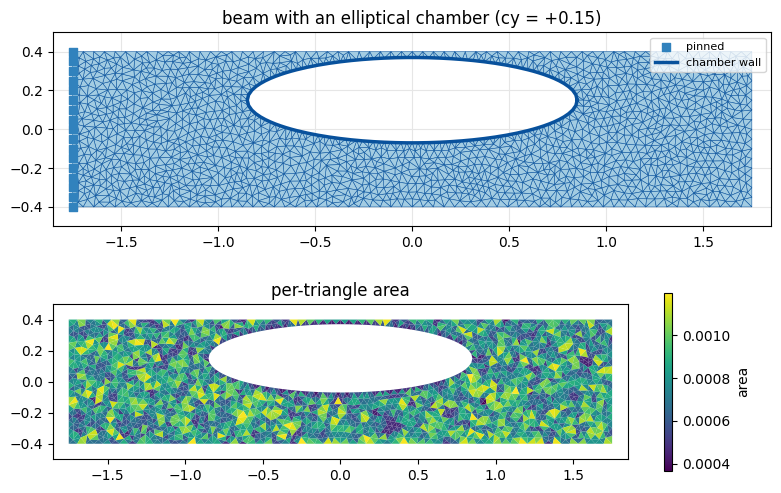

In [3]:
vol = simkit.volume(X, T)
print(f"triangle areas from {vol.min():.1e} to {vol.max():.1e}   (MAX_AREA = {MAX_AREA})")
loop = np.append(E_chamber[:, 0], E_chamber[0, 0])                 # closed wall polyline
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 5.2))
utils.plot_mesh(ax0, X, T, pins=pin_idx, lw=0.4, title=f"beam with an elliptical chamber (cy = {CY_DEMO:+.2f})")
ax0.plot(X[loop, 0], X[loop, 1], "-", color="#08519c", lw=2.5, zorder=4, label="chamber wall")
ax0.legend(loc="upper right", fontsize=8)
utils.plot_scalar_field(ax1, X, T, vol, title="per-triangle area", label="area", edges=False)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "015_mesh.png"))
plt.show()

## The pneumatic energy

`pneumatic_system` sums three terms, one per line: neo-Hookean elasticity, the clamp penalty, and the
chamber term $\tfrac12 k\,(A(x)-A^\star)^2$ with gradient $k\,(A-A^\star)\,\nabla A$.
`outline_areas_gradient` returns $\nabla A$ on the wall vertices only, so the selection matrix $S$
from `outline_selection_matrices` (expanded to x/y DOFs) scatters it onto the whole mesh. The chamber
Hessian keeps only the Gauss–Newton part $k\,\nabla A\,\nabla A^\top$, which is rank-1 and PSD. It
drops the indefinite $k\,(A-A^\star)\nabla^2 A$, so every Newton system stays positive-definite.

In [4]:
def pneumatic_system(X, T, E_chamber, pin_idx, A_target):
    """Neo-Hookean beam + clamped wall + one chamber driven toward the commanded area A_target."""
    n, dim = X.shape
    J = simkit.deformation_jacobian(X, T)
    vol = simkit.volume(X, T)
    mu, lam = simkit.ympr_to_lame(YM, PR)
    mu = np.full((len(T), 1), mu)
    lam = np.full((len(T), 1), lam)
    Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)
    S = simkit.outline_selection_matrices([E_chamber], n)[0]      # global vertices -> wall vertices
    S = sp.sparse.kron(S, sp.sparse.eye(dim)).tocsr()              # ... on interleaved x/y DOFs

    def area(x):
        return simkit.outline_areas(x.reshape(n, dim), [E_chamber])[0]

    def area_gradient(x):                                          # (1, 2 * wall vertices)
        return simkit.outline_areas_gradient(x.reshape(n, dim), [E_chamber])[0]

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_pneumatic = 0.5 * K_INFLATE * (area(x) - A_target) ** 2
        E_total = E_elastic + E_pin + E_pneumatic
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_pneumatic = K_INFLATE * (area(x) - A_target) * (S.T @ area_gradient(x).T)
        g_total = g_elastic + g_pin + g_pneumatic
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        grad_A = area_gradient(x)
        H_pneumatic = K_INFLATE * (S.T @ sp.sparse.csr_matrix(grad_A.T @ grad_A) @ S)   # Gauss-Newton
        H_total = H_elastic + H_pin + H_pneumatic
        return H_total

    return energy_func, gradient_func, hessian_func

The chamber's force is $-k\,(A-A^\star)\,\nabla A = p\,\nabla A$ with $p = k\,(A^\star - A)$. The
shoelace gradient $\nabla A$ at a wall vertex is half the sum of its two edges' outward normals,
so the term is exactly a **pressure load** with internal pressure $p$. The arrows show $\nabla A$
at rest: every one points out of the chamber, into the material, with nearly equal length because
`ellipse_outline` spaces the wall vertices evenly by arc length.

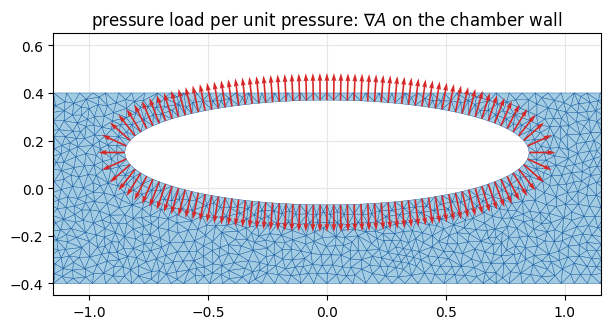

In [5]:
wall = X[np.unique(E_chamber)]                                     # local order of outline_areas_gradient
grad_A = simkit.outline_areas_gradient(X, [E_chamber])[0].reshape(-1, 2)
fig, ax = plt.subplots(figsize=(8, 3.4))
utils.plot_mesh(ax, X, T, lw=0.3, lims=((-1.15, 1.15), (-0.45, 0.65)),
                title=r"pressure load per unit pressure: $\nabla A$ on the chamber wall")
ax.quiver(wall[:, 0], wall[:, 1], grad_A[:, 0], grad_A[:, 1], color="#d62728", zorder=6,
          angles="xy", scale_units="xy", scale=0.25, width=0.003)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "pressure_load.png"),
                              copy_to=os.path.join(MEDIA_DIR, "015_pressure_load.png"))
plt.show()

A central-difference check of the assembled gradient before simulating. At a randomly perturbed
state (clamp kept exact) with the final commanded area, `simkit.gradient_cfd` differentiates
$t \mapsto E(x + t\,d)$ along a random unit direction $d$, and we compare with $\nabla E \cdot d$.
The error falls like $h^2$ (dashed guide) to a few $10^{-6}$ near $h = 10^{-3}$. Below that,
round-off takes over, amplified by the large constant in the clamp penalty's energy.

grad E . d = 1.260745e+03; best relative FD error 2.4e-06 at h = 1e-03


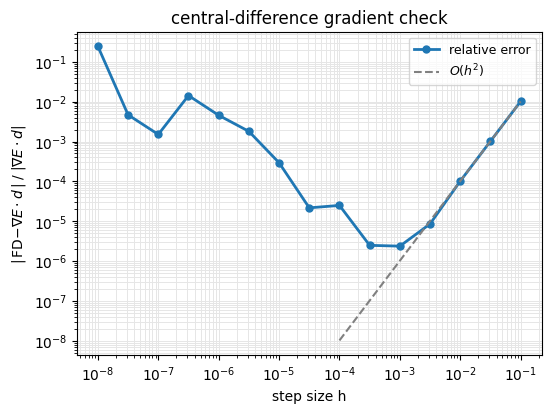

In [6]:
rng = np.random.default_rng(SEED)
energy_func, gradient_func, hessian_func = pneumatic_system(X, T, E_chamber, pin_idx, GROWTH * A_rest)
U_test = X + FD_NOISE * rng.standard_normal(X.shape)
U_test[pin_idx] = X[pin_idx]
x_test = U_test.reshape(-1, 1)
d = rng.standard_normal(x_test.shape)
d /= np.linalg.norm(d)
directional = (gradient_func(x_test).T @ d).item()
fd = np.array([simkit.gradient_cfd(lambda t: np.array([energy_func(x_test + t[0] * d)]), np.zeros(1), h)[0, 0]
               for h in FD_STEPS])
rel_err = np.abs(fd - directional) / abs(directional)
print(f"grad E . d = {directional:.6e}; best relative FD error {rel_err.min():.1e} at h = {FD_STEPS[rel_err.argmin()]:.0e}")

fig, ax = utils.loglog_plot(FD_STEPS, {"relative error": rel_err},
                            xlabel="step size h", ylabel=r"$|\,$FD$ - \nabla E\cdot d\,| \;/\; |\nabla E\cdot d|$",
                            title="central-difference gradient check", figsize=(6, 4.2))
h_guide = FD_STEPS[FD_STEPS >= 1e-4]
ax.loglog(h_guide, rel_err[-1] * (h_guide / FD_STEPS[-1]) ** 2, "--", color="0.5", label=r"$O(h^2)$")
ax.legend(fontsize=9)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "gradient_check.png"),
                              copy_to=os.path.join(MEDIA_DIR, "015_gradient_check.png"))
plt.show()

## Quasistatically inflating the chamber

There is no time, mass or velocity here. `inflate` ramps the commanded area $A^\star$ from $A_\text{rest}$
to `GROWTH`$\,\cdot A_\text{rest}$ in `N_STEPS` load steps. At each step it rebuilds the system with the new
$A^\star$ and Newton-solves for static equilibrium, warm-started from the previous pose, and records the
achieved area, the pressure $p = k\,(A^\star - A)$ and Newton's gradient-norm history. `tip_deflection`
measures the free end's mean vertical displacement and the angle it subtends over the beam length.
We run the demo beam, whose chamber sits above the center line.

In [7]:
def inflate(X, T, E_chamber, pin_idx):
    """Ramp the commanded chamber area to GROWTH x rest, Newton-solving each load step."""
    A_rest = simkit.outline_areas(X, [E_chamber])[0]
    x = X.reshape(-1, 1).copy()
    run = {"states": [X.copy()], "targets": [A_rest], "areas": [A_rest], "pressures": [0.0],
           "iters": [], "grad_norms": []}
    for A_target in np.linspace(A_rest, GROWTH * A_rest, N_STEPS + 1)[1:]:
        energy_func, gradient_func, hessian_func = pneumatic_system(X, T, E_chamber, pin_idx, A_target)
        x, info = simkit.solvers.newton_solver(x, energy_func, gradient_func, hessian_func,
                                               max_iter=NEWTON_ITERS, do_line_search=True, return_info=True)
        A = simkit.outline_areas(x.reshape(-1, 2), [E_chamber])[0]
        run["states"].append(x.reshape(-1, 2).copy())
        run["targets"].append(A_target)
        run["areas"].append(A)
        run["pressures"].append(K_INFLATE * (A_target - A))
        run["iters"].append(info["iters"] + 1)
        run["grad_norms"].append([np.linalg.norm(g) for g in info["g"]] + [np.linalg.norm(gradient_func(x))])
    return run


def tip_deflection(X, U):
    """Mean vertical displacement of the free right end, and its angle (degrees) over the beam length."""
    tip = np.where(X[:, 0] >= X[:, 0].max() - 1e-6)[0]
    dy = U[tip, 1].mean() - X[tip, 1].mean()
    angle = np.degrees(np.arctan2(dy, BEAM_L))
    return dy, angle


demo = inflate(X, T, E_chamber, pin_idx)
dy, angle = tip_deflection(X, demo["states"][-1])
tip_path = [tip_deflection(X, U)[0] for U in demo["states"]]
k_up = int(np.argmax(tip_path))
print(f"chamber area {demo['areas'][0]:.3f} -> {demo['areas'][-1]:.3f}  (x{demo['areas'][-1] / demo['areas'][0]:.2f})")
print(f"final tip deflection {dy:+.3f}  (tip angle {angle:+.1f} deg); "
      f"on the way the tip first rises to {tip_path[k_up]:+.3f} at A = {demo['areas'][k_up]:.2f}")
print(f"peak chamber pressure p = {max(demo['pressures']):.1f}")
print(f"Newton iterations per load step: {min(demo['iters'])} to {max(demo['iters'])}")

chamber area 0.587 -> 2.052  (x3.49)
final tip deflection -0.291  (tip angle -4.7 deg); on the way the tip first rises to +0.262 at A = 1.01
peak chamber pressure p = 294.9
Newton iterations per load step: 4 to 30


The inflation, one frame per load step. Left: the beam holding still at each inflation level. While
the flat ellipse rounds up, its width shrinks and pulls the top edge in, so the tip first *rises*;
once the thin top wall has to stretch, it lengthens the top edge and the beam ends up curled down.
Right: the chamber's pressure–area curve, which rises slowly, steepens, and then flattens as the
stretched, thinned wall gets easier to inflate.

In [8]:
fig, anim = utils.animate_chamber_trace(demo["states"], T, E_chamber[:, 0], demo["areas"],
                                        {"pressure": demo["pressures"]}, pins=pin_idx, fps=FPS,
                                        title="chamber near the top wall -> beam curls down",
                                        xlabel="chamber area A", ylabel=r"pressure $p = k(A^\star - A)$",
                                        trace_title="pressure vs. chamber area", colors={"pressure": "#08519c"})
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "pneumatic_inflate.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "015_pneumatic_inflate.mp4"))
plt.close(fig)
utils.embed_video(video)

Three cheap checks on the demo run. Left: the soft constraint's miss $A^\star - A = p/k$ stays below
0.15% of the target, so `K_INFLATE` is stiff enough. Middle: Newton needs 4 to 30 iterations per load
step. Right: the gradient norm per Newton iteration at the first, middle and last load step. The
unpressurized first step converges quadratically; under pressure the dropped $-p\,\nabla^2 A$ term makes
Gauss–Newton converge only linearly, until the line search stalls at round-off.

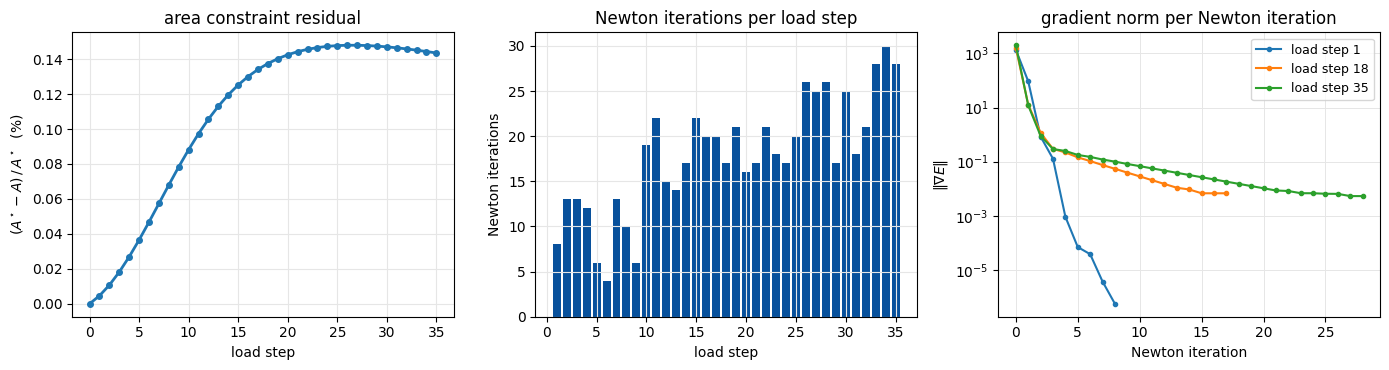

In [9]:
targets = np.array(demo["targets"])
residual = (targets - np.array(demo["areas"])) / targets
steps = np.arange(N_STEPS + 1)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
utils.line_plot(steps, {"residual": 100 * residual}, ax=axes[0], markers=True, xlabel="load step",
                ylabel=r"$(A^\star - A)\,/\,A^\star$  (%)", title="area constraint residual")
axes[1].bar(steps[1:], demo["iters"], color="#08519c")
axes[1].set(xlabel="load step", ylabel="Newton iterations", title="Newton iterations per load step")
axes[1].grid(True, color="0.9", linewidth=0.8)
for k in [0, N_STEPS // 2, N_STEPS - 1]:
    axes[2].semilogy(demo["grad_norms"][k], "-o", ms=3, label=f"load step {k + 1}")
axes[2].set(xlabel="Newton iteration", ylabel=r"$\|\nabla E\|$", title="gradient norm per Newton iteration")
axes[2].grid(True, which="both", color="0.9", linewidth=0.7)
axes[2].legend(fontsize=9)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "inflation_diagnostics.png"),
                              copy_to=os.path.join(MEDIA_DIR, "015_inflation_diagnostics.png"))
plt.show()

Where the material deforms at full inflation, per triangle from `simkit.deformation_gradient`. Top: the
largest principal stretch (largest singular value of $F$); the thin top wall is stretched to about 2.5×
around the dome while the thick bottom wall barely stretches, and this asymmetry bends the beam.
Bottom: $\det F$ stays within about 20% of 1 (Poisson ratio 0.45), so the stretched wall must thin.

largest principal stretch 2.50; det F from 0.91 to 1.20


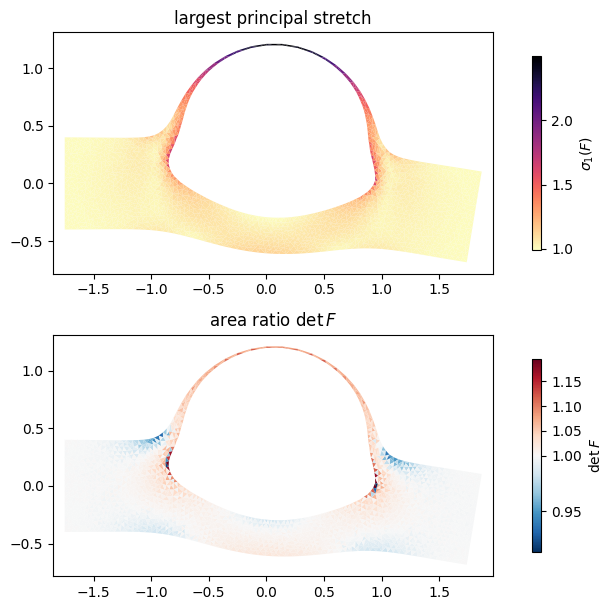

In [10]:
U_final = demo["states"][-1]
F = simkit.deformation_gradient(X, T, U_final).reshape(-1, 2, 2)
stretch = np.linalg.svd(F, compute_uv=False)[:, 0]
print(f"largest principal stretch {stretch.max():.2f}; det F from {np.linalg.det(F).min():.2f} to {np.linalg.det(F).max():.2f}")
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 6.2))
utils.plot_scalar_field(ax0, U_final, T, stretch, cmap="magma_r", edges=False,
                        title="largest principal stretch", label=r"$\sigma_1(F)$")
utils.plot_scalar_field(ax1, U_final, T, np.linalg.det(F), cmap="RdBu_r", edges=False,
                        norm=TwoSlopeNorm(vcenter=1.0), title=r"area ratio $\det F$", label=r"$\det F$")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "stretch.png"),
                              copy_to=os.path.join(MEDIA_DIR, "015_stretch.png"))
plt.show()

## Steering: where you put the chamber sets the bend

The chamber height `cy` is the actuator's design knob. Above the center line it leaves a thin, compliant
top wall that stretches far more than the thick bottom wall, so the beam curls **down**; below, it curls
**up**; centered, it only swells. We build one mesh per height in `CY_SWEEP`, shown here at rest with the
center line dashed.

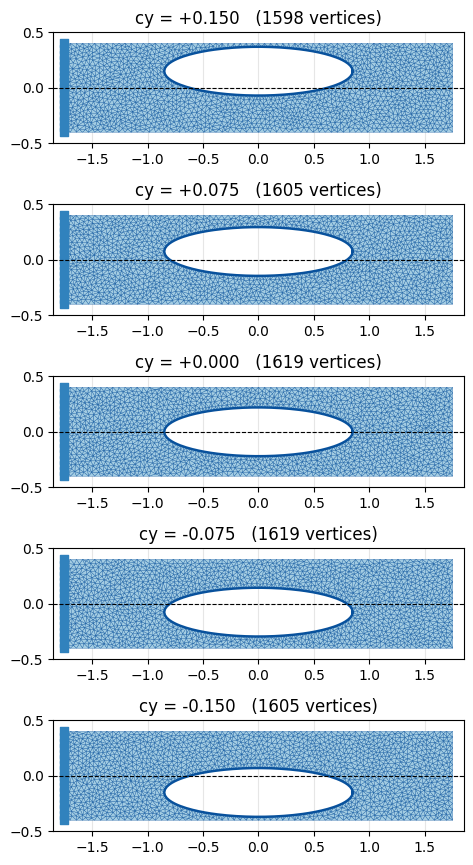

In [11]:
designs = {cy: chamber_beam(cy) for cy in CY_SWEEP}
fig, axes = plt.subplots(len(CY_SWEEP), 1, figsize=(7, 1.75 * len(CY_SWEEP)))
for ax, cy in zip(axes, CY_SWEEP):
    Xd, Td, Ed, pins_d = designs[cy]
    loop_d = np.append(Ed[:, 0], Ed[0, 0])
    utils.plot_mesh(ax, Xd, Td, pins=pins_d, lw=0.25, title=f"cy = {cy:+.3f}   ({len(Xd)} vertices)")
    ax.plot(Xd[loop_d, 0], Xd[loop_d, 1], "-", color="#08519c", lw=1.8, zorder=4)
    ax.axhline(0.0, color="k", ls="--", lw=0.8, zorder=5)
    ax.get_legend().remove()
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "designs.png"),
                              copy_to=os.path.join(MEDIA_DIR, "015_designs.png"))
plt.show()

Inflate every design with the same ramp (about a minute; the demo run is reused) and report its tip
deflection and peak pressure. The response is antisymmetric in `cy`, and the centered chamber needs
more than twice the peak pressure of the `cy = ±0.15` ones, because both of its walls are thick.

In [12]:
assert set(CY_STEERING) <= set(CY_SWEEP)
runs = {CY_DEMO: demo}
for cy in CY_SWEEP:
    if cy not in runs:
        runs[cy] = inflate(*designs[cy])
tips = {cy: tip_deflection(designs[cy][0], runs[cy]["states"][-1]) for cy in CY_SWEEP}
for cy in CY_SWEEP:
    print(f"cy = {cy:+.3f}   tip dy = {tips[cy][0]:+.3f}   tip angle = {tips[cy][1]:+.1f} deg   "
          f"peak pressure = {max(runs[cy]['pressures']):5.0f}")

cy = +0.150   tip dy = -0.291   tip angle = -4.7 deg   peak pressure =   295
cy = +0.075   tip dy = -0.105   tip angle = -1.7 deg   peak pressure =   586
cy = +0.000   tip dy = -0.001   tip angle = -0.0 deg   peak pressure =   674
cy = -0.075   tip dy = +0.105   tip angle = +1.7 deg   peak pressure =   585
cy = -0.150   tip dy = +0.288   tip angle = +4.7 deg   peak pressure =   295


Three of those runs side by side: the same inflation with the chamber high, centered and low ends with
the beam bent down, straight, and up (titles give the final tip angle).

In [13]:
panels = [{"states": runs[cy]["states"], "T": designs[cy][1], "loop": designs[cy][2][:, 0],
           "pins": designs[cy][3], "title": f"cy = {cy:+.2f}:  final tip angle {tips[cy][1]:+.1f} deg"}
          for cy in CY_STEERING]
fig, anim = utils.animate_chamber_panels(panels, fps=FPS, suptitle="same inflation, three chamber placements")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "pneumatic_steering.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "015_pneumatic_steering.mp4"))
plt.close(fig)
utils.embed_video(video)

## A deflection gallery

Every design's fully inflated pose over its rest silhouette (gray), labeled with its tip angle: sweeping
one design parameter gives a continuous fan of deflections.

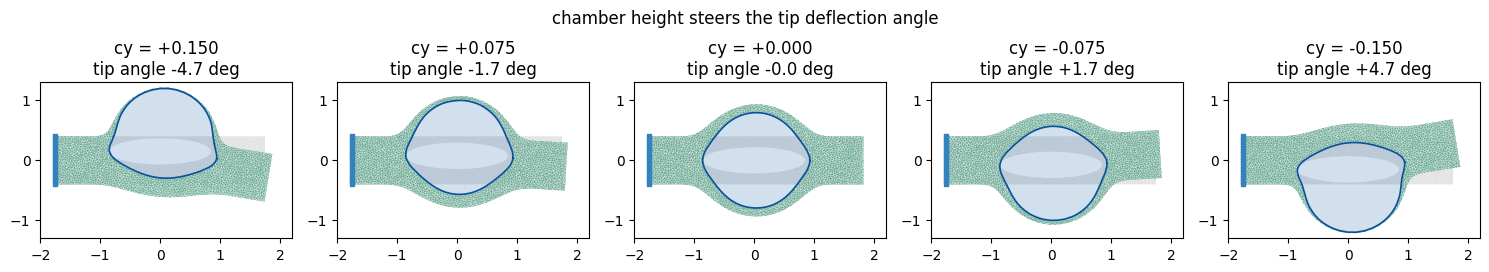

In [14]:
fig, axes = plt.subplots(1, len(CY_SWEEP), figsize=(3.0 * len(CY_SWEEP), 2.8))
for ax, cy in zip(axes, CY_SWEEP):
    Xd, Td, Ed, pins_d = designs[cy]
    utils.ChamberMeshArtist(ax, runs[cy]["states"][-1], Td, Ed[:, 0], rest=Xd, pins=pins_d,
                            lw=0.15, wall_lw=1.2, pin_size=6)
    utils.setup_axes(ax, (-2.0, 2.2), (-1.3, 1.3), title=f"cy = {cy:+.3f}\ntip angle {tips[cy][1]:+.1f} deg",
                     grid=False)
fig.suptitle("chamber height steers the tip deflection angle")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "pneumatic_gallery.png"),
                              copy_to=os.path.join(MEDIA_DIR, "015_pneumatic_gallery.png"))
plt.show()

The sweep in three plots (dashed: chamber below the center line). Left: final tip angle against chamber
height, antisymmetric through zero and steepening with the offset. Middle: the tip's path over the ramp;
every off-center design first moves the "wrong" way, then reverses. Right: pressure–area curves; mirror
designs coincide, and off-center chambers reach the same area at far lower pressure through their thin wall.

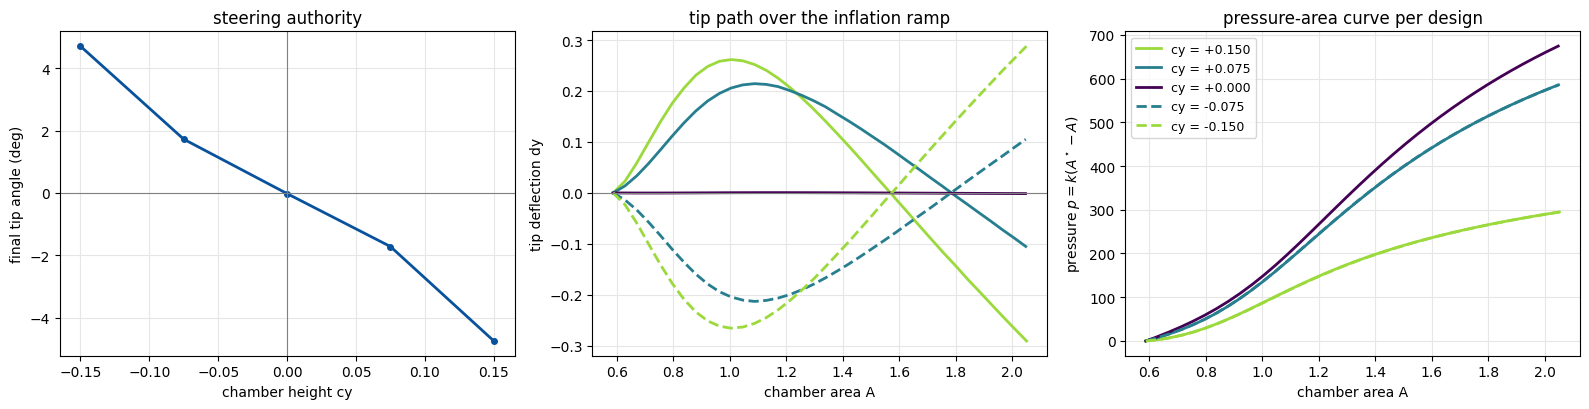

In [15]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(16, 4.2))
utils.line_plot(CY_SWEEP, {"tip angle": [tips[cy][1] for cy in CY_SWEEP]}, ax=ax0, markers=True,
                colors={"tip angle": "#08519c"}, xlabel="chamber height cy", ylabel="final tip angle (deg)",
                title="steering authority")
ax0.axhline(0.0, color="0.5", lw=0.8)
ax0.axvline(0.0, color="0.5", lw=0.8)
max_cy = max(abs(cy) for cy in CY_SWEEP)
for cy in CY_SWEEP:
    style = dict(color=plt.cm.viridis(0.85 * abs(cy) / max_cy), ls="-" if cy >= 0 else "--", lw=2,
                 label=f"cy = {cy:+.3f}")
    ax1.plot(runs[cy]["areas"], [tip_deflection(designs[cy][0], U)[0] for U in runs[cy]["states"]], **style)
    ax2.plot(runs[cy]["areas"], runs[cy]["pressures"], **style)
ax1.axhline(0.0, color="0.5", lw=0.8)
ax1.set(xlabel="chamber area A", ylabel="tip deflection dy", title="tip path over the inflation ramp")
ax2.set(xlabel="chamber area A", ylabel=r"pressure $p = k(A^\star - A)$", title="pressure-area curve per design")
ax1.grid(True, color="0.9", linewidth=0.8)
ax2.grid(True, color="0.9", linewidth=0.8)
ax2.legend(fontsize=9, loc="upper left")                          # line styles are shared by both panels
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "sweep_summary.png"),
                              copy_to=os.path.join(MEDIA_DIR, "015_sweep_summary.png"))
plt.show()

### Takeaways

* A sealed chamber is a **signed-area outline energy** $\tfrac12 k\,(A(x)-A^\star)^2$; its force
  $p\,\nabla A$ is a genuine **pressure load** on the wall, with $p = k\,(A^\star - A)$.
* Coupled to full-order neo-Hookean FEM and a clamped wall, ramping $A^\star$ and re-solving with Newton
  gives a clean **quasistatic** inflation and the actuator's pressure–area curve.
* The Gauss–Newton chamber Hessian $k\,\nabla A\,\nabla A^\top$ keeps every solve positive-definite, at
  the price of linear convergence once the chamber is pressurized.
* **Placement is steering**: an off-center chamber stretches its thin wall and bends the cantilever, and
  the offset sets the tip angle (after an initial reverse motion). Real soft robots chain many such
  chambers to reach, grip and crawl.